In [45]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.spread import compute_spread
from src.z_score import compute_rolling_z
from src.signals import generate_signals


adj_close_df = pd.read_csv("../data/processed/adj_close_prices.csv", index_col=0, parse_dates=True)
cointegrated_pair = ('JBLU', 'LUV', np.float64(0.9504446769104575), np.float64(7.109656764761808e-05))


## Calculating spread and z scores

In [46]:
spread = compute_spread(adj_close_df, cointegrated_pair)[2]
print(spread)

Date
2017-01-03   -10.843202
2017-01-04   -10.097636
2017-01-05   -10.209627
2017-01-06    -9.964810
2017-01-09    -9.998275
                ...    
2024-12-24     1.816270
2024-12-26     1.885114
2024-12-27     1.772546
2024-12-30     0.960787
2024-12-31     1.266190
Length: 2012, dtype: float64


In [47]:
rolling_z = compute_rolling_z(spread, 60)
print(rolling_z)

Date
2017-01-03         NaN
2017-01-04         NaN
2017-01-05         NaN
2017-01-06         NaN
2017-01-09         NaN
                ...   
2024-12-24    0.373054
2024-12-26    0.393396
2024-12-27    0.300492
2024-12-30   -0.221469
2024-12-31   -0.043377
Length: 2012, dtype: float64


## Generating Trading Signals

Using the rolling z-score, we define entry and exit rules based on standard mean-reversion thresholds. We enter a position when the z-score exceeds ±2 (indicating the spread has diverged significantly 
from its recent average), and exit when it reverts to near zero. Since a position must be held across multiple days until the exit condition is met, we track state sequentially (via a loop) rather than generating signals independently for each day.

In [48]:
signals = generate_signals(rolling_z)
print(signals)

Date
2017-01-03    0
2017-01-04    0
2017-01-05    0
2017-01-06    0
2017-01-09    0
             ..
2024-12-24    0
2024-12-26    0
2024-12-27    0
2024-12-30    0
2024-12-31    0
Length: 2012, dtype: int64


## Sanity Check

Confirming signal direction matches z-score sign

In [49]:
print(signals[450:550])
print(rolling_z[450:550])

Date
2018-10-16   -1
2018-10-17   -1
2018-10-18   -1
2018-10-19   -1
2018-10-22   -1
             ..
2019-03-06   -1
2019-03-07   -1
2019-03-08   -1
2019-03-11    0
2019-03-12    0
Length: 100, dtype: int64
Date
2018-10-16    1.197254
2018-10-17    1.473906
2018-10-18    1.379556
2018-10-19    1.229900
2018-10-22    0.896550
                ...   
2019-03-06    0.787776
2019-03-07    0.694758
2019-03-08    0.523566
2019-03-11    0.199487
2019-03-12   -0.203497
Length: 100, dtype: float64


## Visualizing Signals

We plot the spread alongside markers showing when the strategy would long (green) or short (red) the pair. Short signals correctly cluster near spread peaks, and long signals near spread troughs, confirming the signal logic behaves as intended before proceeding to backtesting.

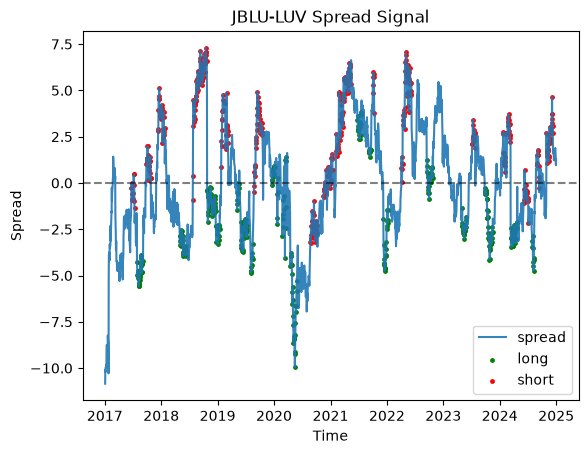

In [50]:
plt.plot(spread, label = "spread", alpha = 0.9)
plt.xlabel("Time")
plt.ylabel("Spread")
plt.title("JBLU-LUV Spread Signal")

long_points = spread[signals == 1]
short_points = spread[signals == -1]

plt.scatter(long_points.index, long_points, color = "green", label = "long", s = 6)
plt.scatter(short_points.index, short_points, color = "red", label = "short", s = 6)

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.legend()
plt.savefig("../figures/jblu_luv_spread_signals.png", dpi=150, bbox_inches="tight")
plt.show()